<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Quest%C3%A3o_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício 4

### Quantização de Coeficientes

Vamos analisar o impacto de representar os coeficientes dos filtros (Questões 2 e 3) com um número limitado de bits ($b \in \{2, 4, 8, 16, 32\}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def quantize_coefficients(coeffs, bits):
    if bits == 32:
        return coeffs.astype(np.float32)

    # Normalização para o intervalo [-1, 1]
    max_val = np.max(np.abs(coeffs))
    if max_val == 0:
        return coeffs

    scaled = coeffs / max_val
    levels = 2**(bits - 1)
    quantized = np.round(scaled * (levels - 1)) / (levels - 1)
    return quantized * max_val

def plot_comparison(b_orig, a_orig, b_quant, a_quant, title):
    w, h_orig = signal.freqz(b_orig, a_orig)
    w, h_quant = signal.freqz(b_quant, a_quant)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(w/np.pi, 20 * np.log10(np.abs(h_orig) + 1e-12), label='Original')
    plt.plot(w/np.pi, 20 * np.log10(np.abs(h_quant) + 1e-12), '--', label='Quantizado')
    plt.title(f'Resposta em Frequência - {title}')
    plt.ylabel('Magnitude (dB)')
    plt.xlabel('Frequência Normalizada (xπ rad/amostra)')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    z_orig, p_orig, k_orig = signal.tf2zpk(b_orig, a_orig)
    z_quant, p_quant, k_quant = signal.tf2zpk(b_quant, a_quant)

    uc = np.exp(1j * np.linspace(0, 2*np.pi, 100))
    plt.plot(uc.real, uc.imag, 'k', alpha=0.3)
    plt.scatter(p_orig.real, p_orig.imag, marker='x', label='Polos Orig')
    plt.scatter(p_quant.real, p_quant.imag, marker='o', facecolors='none', edgecolors='r', label='Polos Quant')
    plt.title('Diagrama de Polos e Zeros')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

### Análise de Sensibilidade Numérica

A seguir, aplicamos a quantização para $b \in \{2, 4, 8, 16, 32\}$ bits.

*Nota: Como os filtros das questões 2 e 3 foram definidos em scripts separados, certifique-se de que os coeficientes `b` e `a` (ou as matrizes `sos`) estejam disponíveis no workspace.*


--- Analisando Filtro Questão 2 (Butterworth) ---
Gerando gráficos para 4 bits...


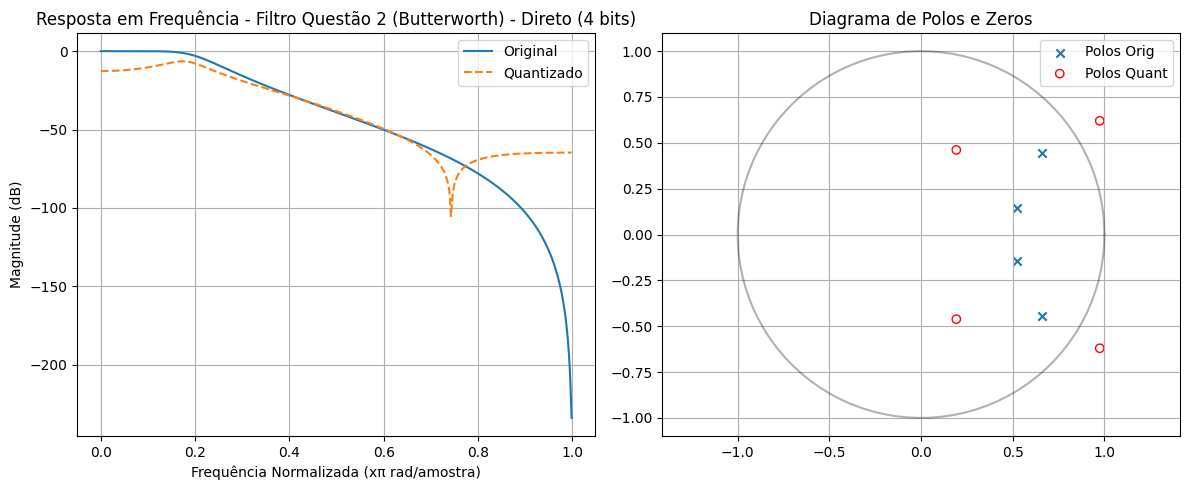

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1235: RuntimeWarning: invalid value encountered in divide
  b = b / b[0]


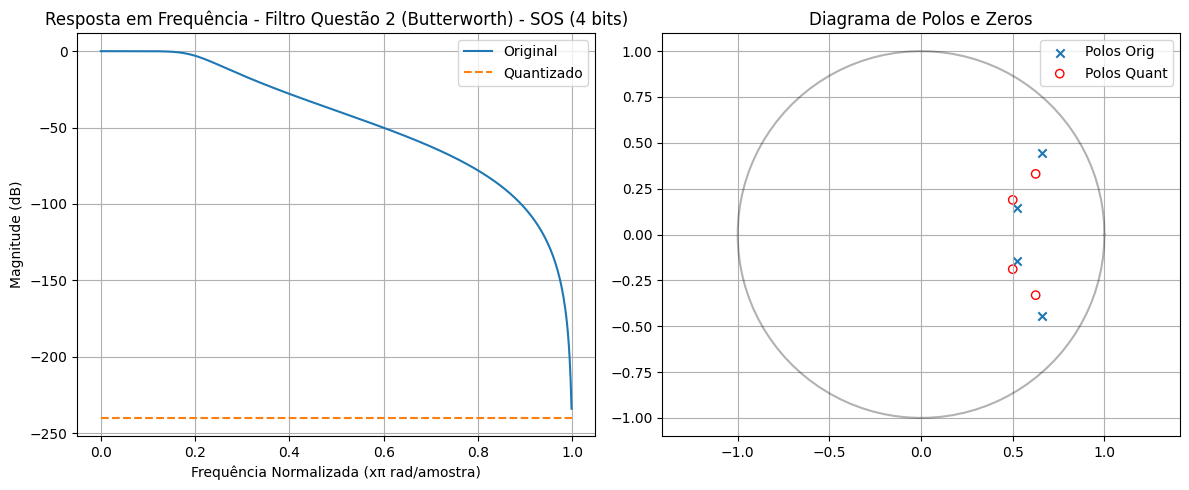

Gerando gráficos para 8 bits...


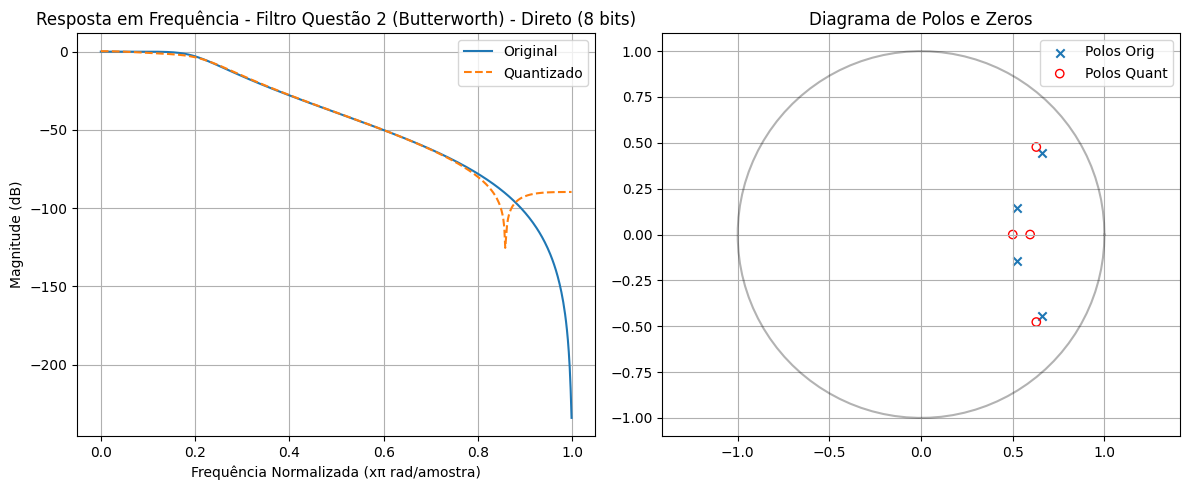

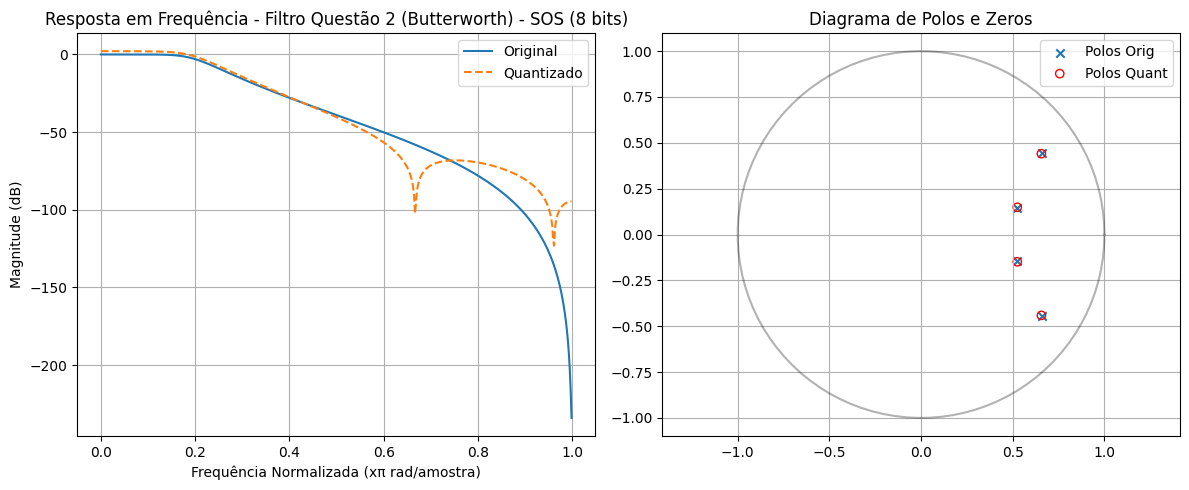

Gerando gráficos para 16 bits...


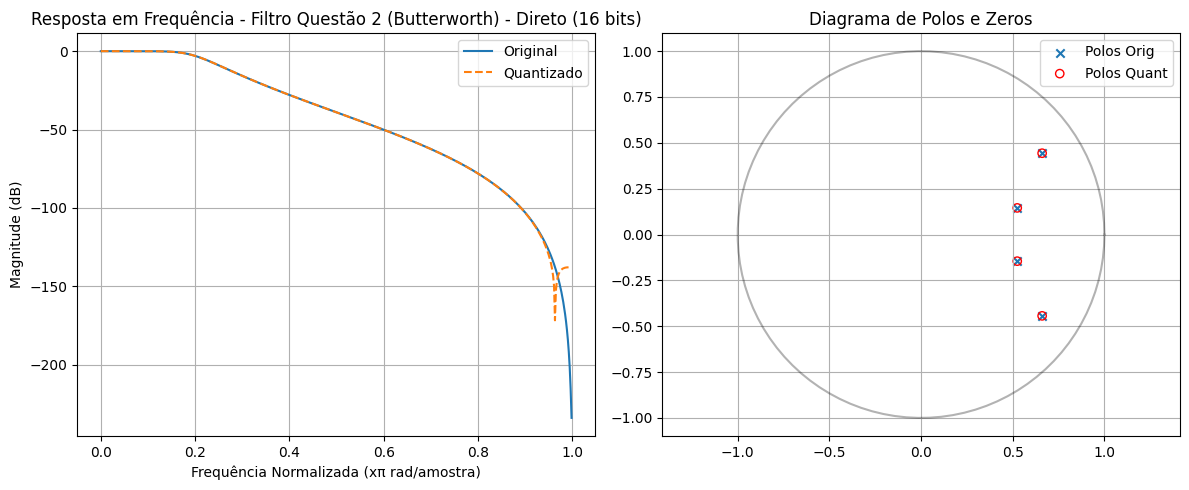

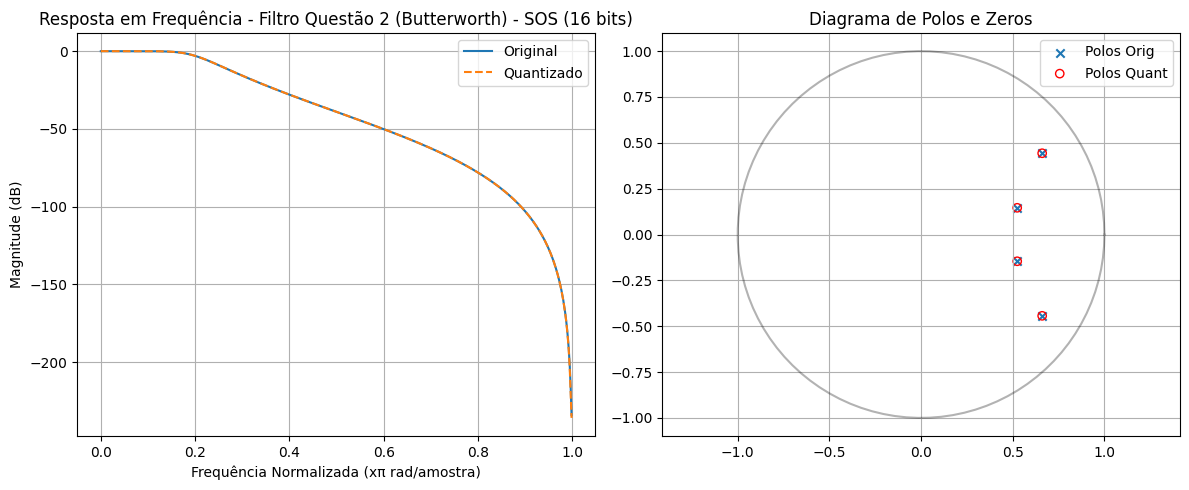


--- Analisando Filtro Questão 3 (Chebyshev) ---
Gerando gráficos para 4 bits...


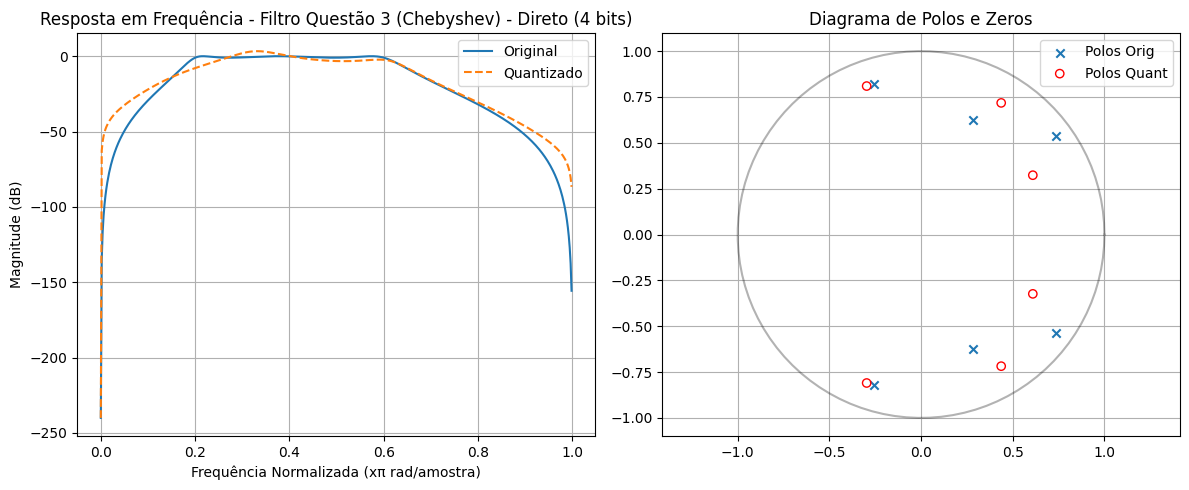

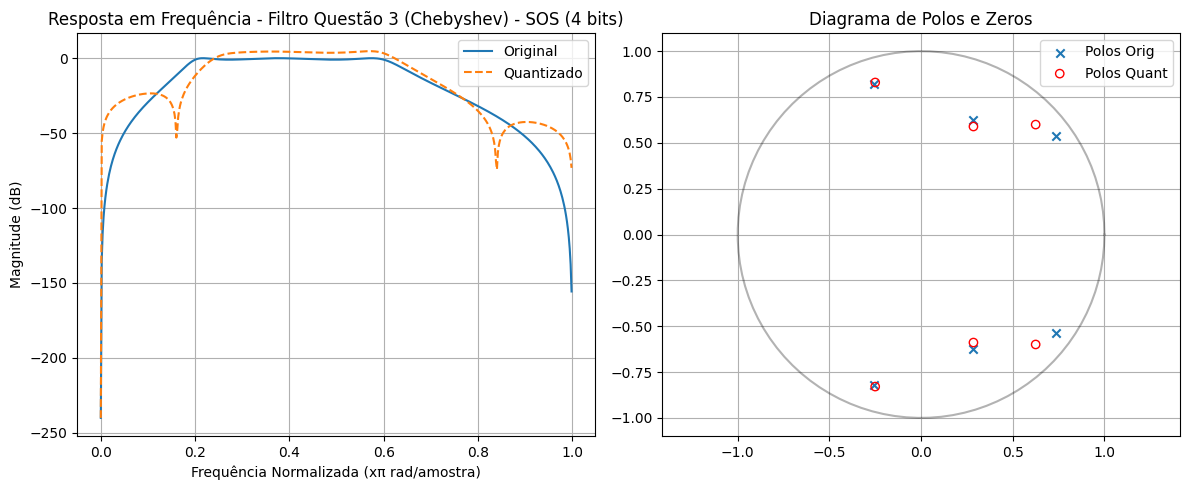

Gerando gráficos para 8 bits...


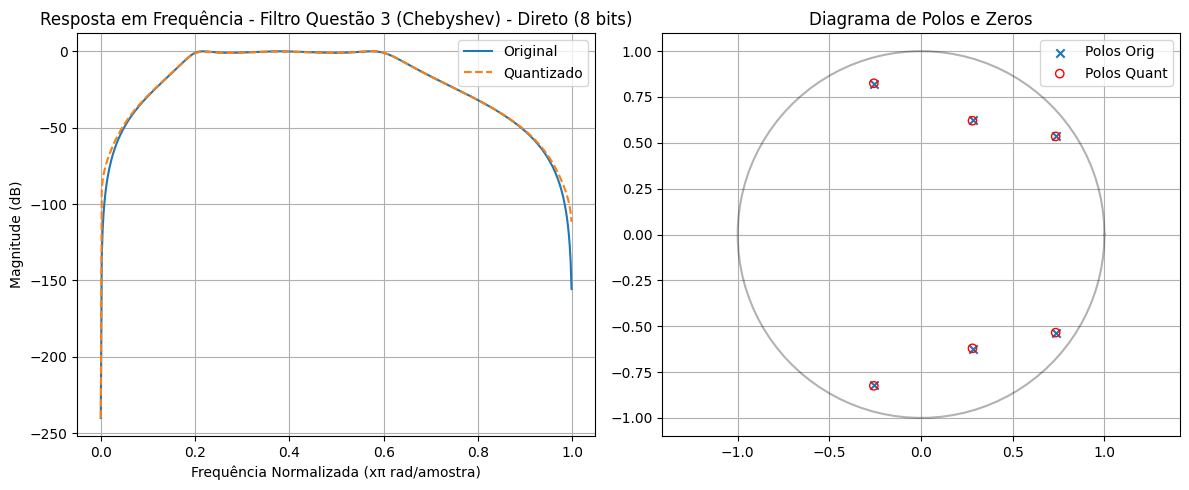

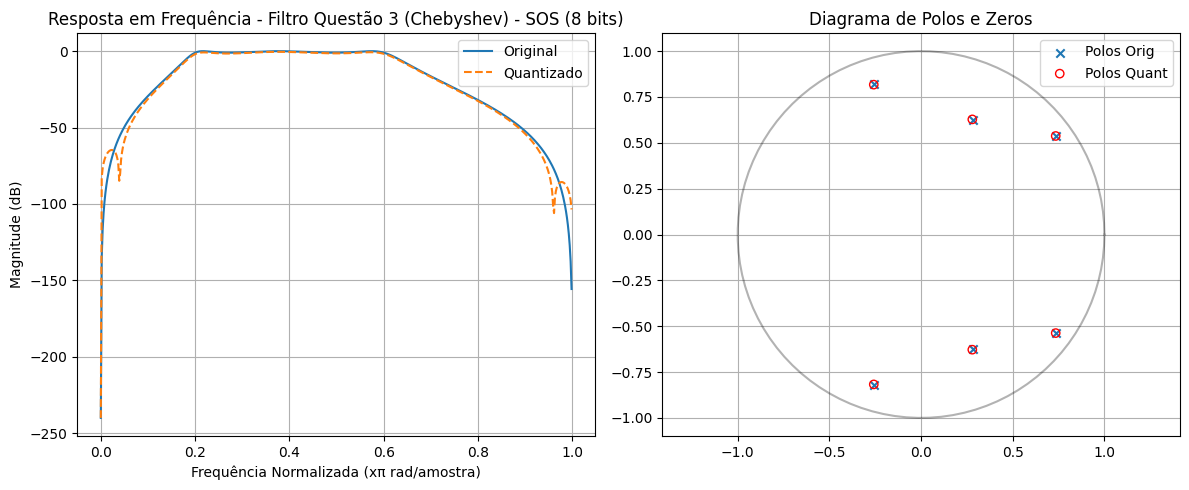

Gerando gráficos para 16 bits...


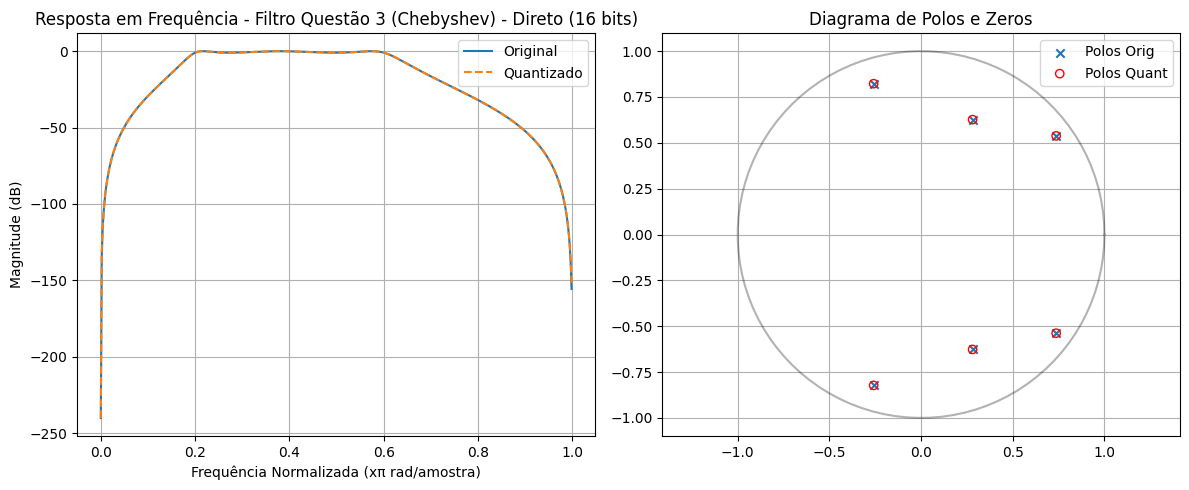

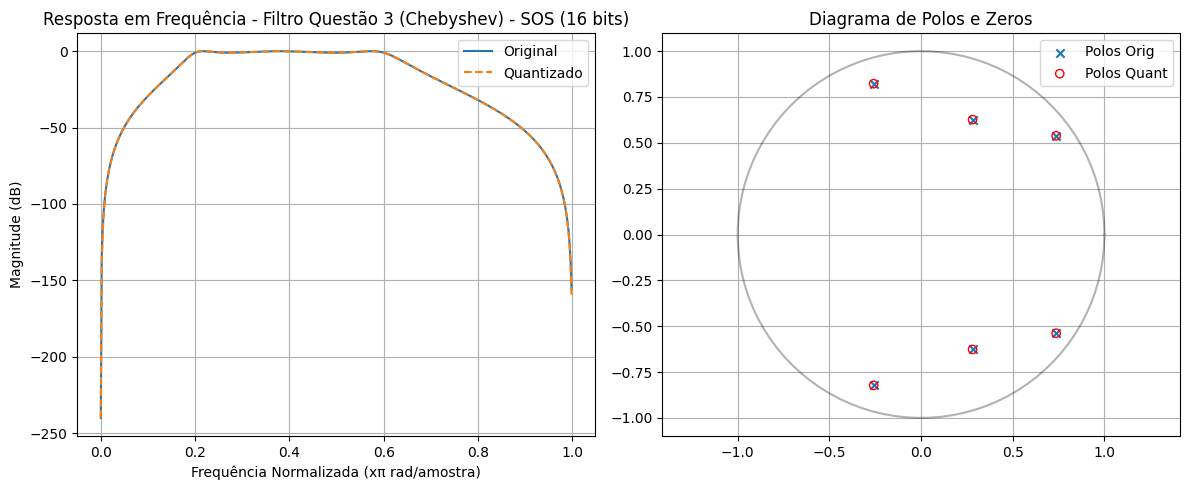

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Reprojetando os filtros para garantir disponibilidade dos coeficientes
fs = 1000

# Filtro Questão 2 (Butterworth Passa-Baixas)
order2 = 4
fc2 = 100
b2, a2 = signal.butter(order2, fc2/(fs/2), btype='low')
sos2 = signal.butter(order2, fc2/(fs/2), btype='low', output='sos')

# Filtro Questão 3 (Chebyshev Tipo I Passa-Faixa)
order3 = 3
ripple = 1
fc3 = [100, 300]
b3, a3 = signal.cheby1(order3, ripple, [f/(fs/2) for f in fc3], btype='bandpass')
sos3 = signal.cheby1(order3, ripple, [f/(fs/2) for f in fc3], btype='bandpass', output='sos')

bits_list = [2, 4, 8, 16, 32]

def analyze_quantization(b_orig, a_orig, sos_orig, label):
    print(f'\n--- Analisando {label} ---')
    for b in bits_list:
        # 1. Quantização Direta
        bq = quantize_coefficients(b_orig, b)
        aq = quantize_coefficients(a_orig, b)

        # 2. Quantização por Bloco (SOS)
        sos_q = np.array([quantize_coefficients(section, b) for section in sos_orig])

        if b in [4, 8, 16]:
            print(f'Gerando gráficos para {b} bits...')
            # Forma Direta
            plot_comparison(b_orig, a_orig, bq, aq, f'{label} - Direto ({b} bits)')
            # Forma SOS
            bq_sos, aq_sos = signal.sos2tf(sos_q)
            plot_comparison(b_orig, a_orig, bq_sos, aq_sos, f'{label} - SOS ({b} bits)')

analyze_quantization(b2, a2, sos2, 'Filtro Questão 2 (Butterworth)')
analyze_quantization(b3, a3, sos3, 'Filtro Questão 3 (Chebyshev)')


--- Analisando Questão 2 (Butterworth) ---
Bits: 2 | Estável (Direta): False
Bits: 4 | Estável (Direta): False

Gerando gráficos para 4 bits...


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


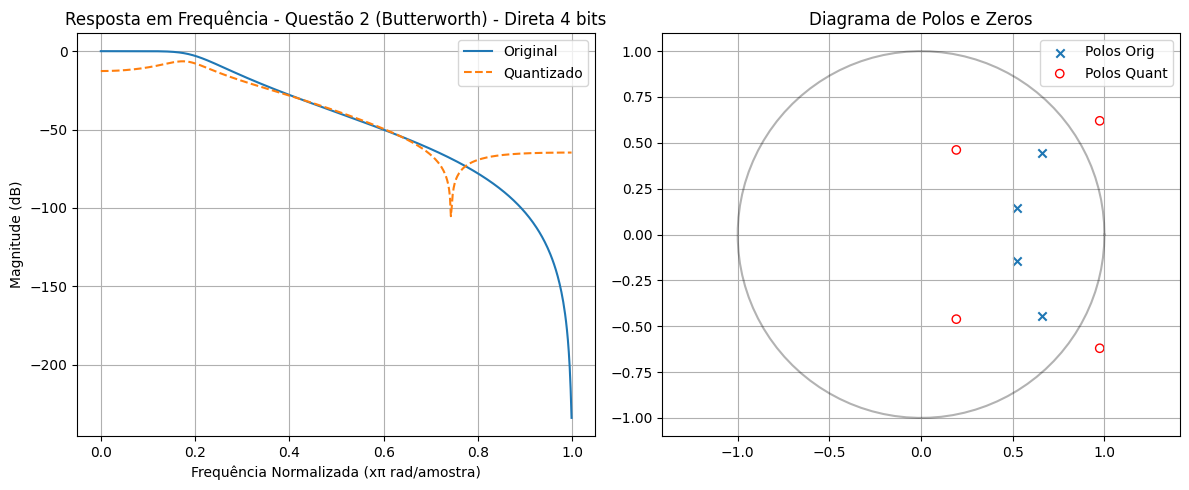

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1235: RuntimeWarning: invalid value encountered in divide
  b = b / b[0]


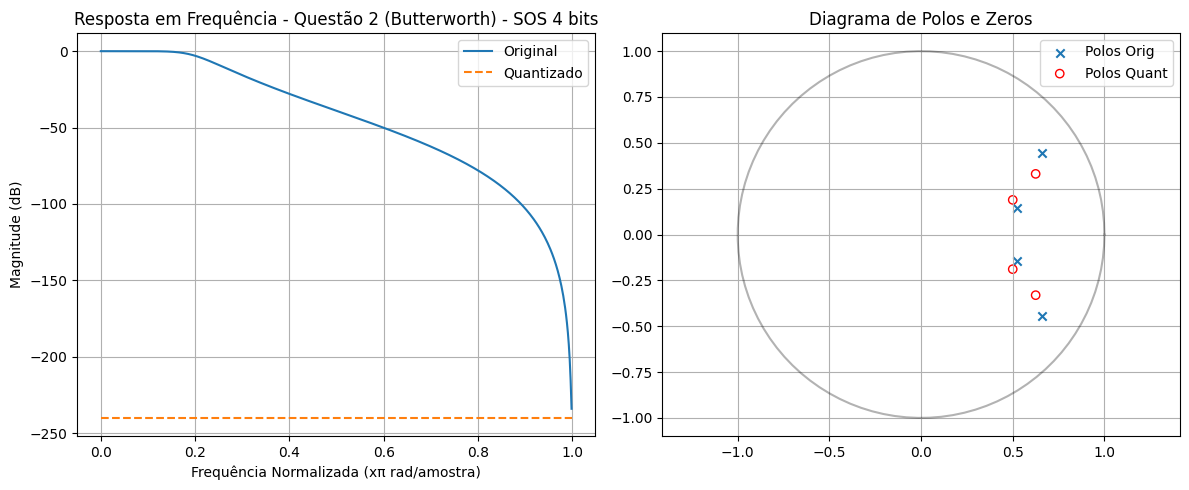

Bits: 8 | Estável (Direta): True

Gerando gráficos para 8 bits...


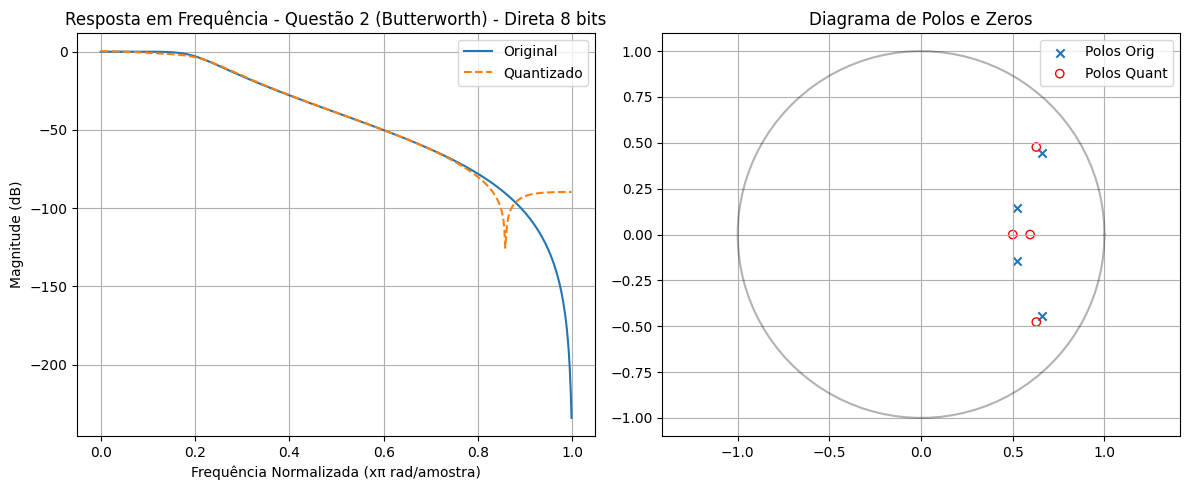

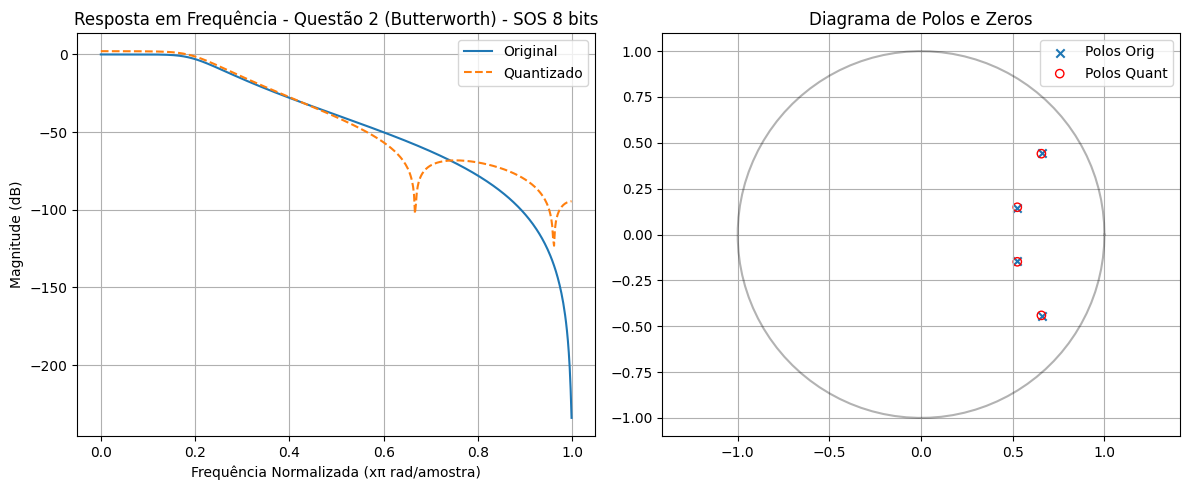

Bits: 16 | Estável (Direta): True

Gerando gráficos para 16 bits...


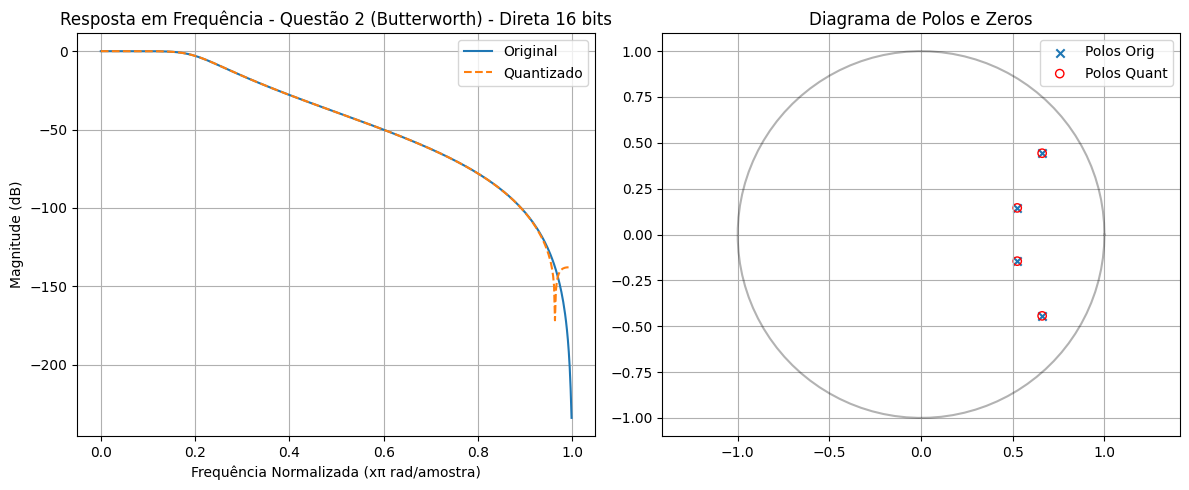

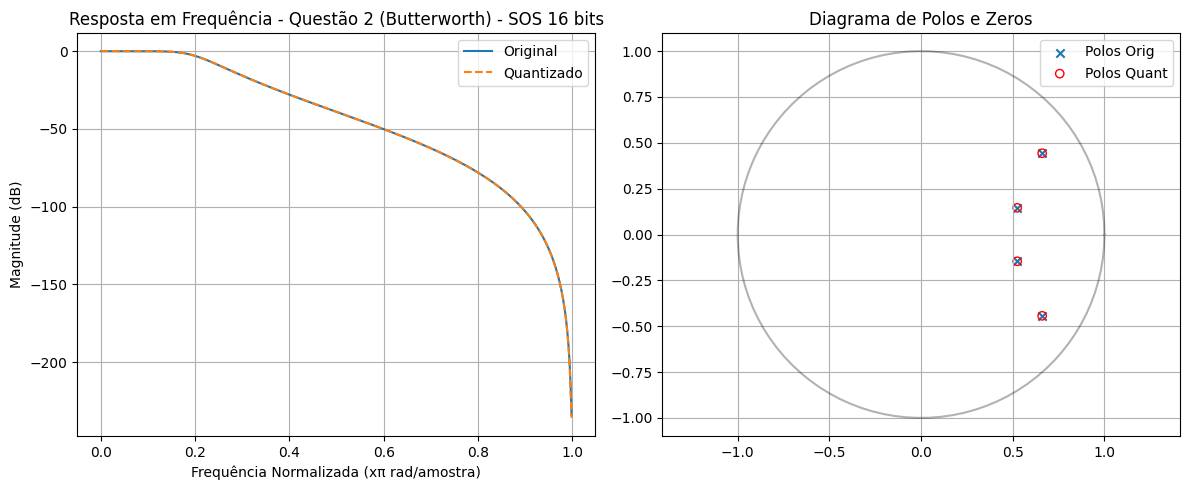

Bits: 32 | Estável (Direta): True

--- Analisando Questão 3 (Chebyshev) ---
Bits: 2 | Estável (Direta): True
Bits: 4 | Estável (Direta): True

Gerando gráficos para 4 bits...


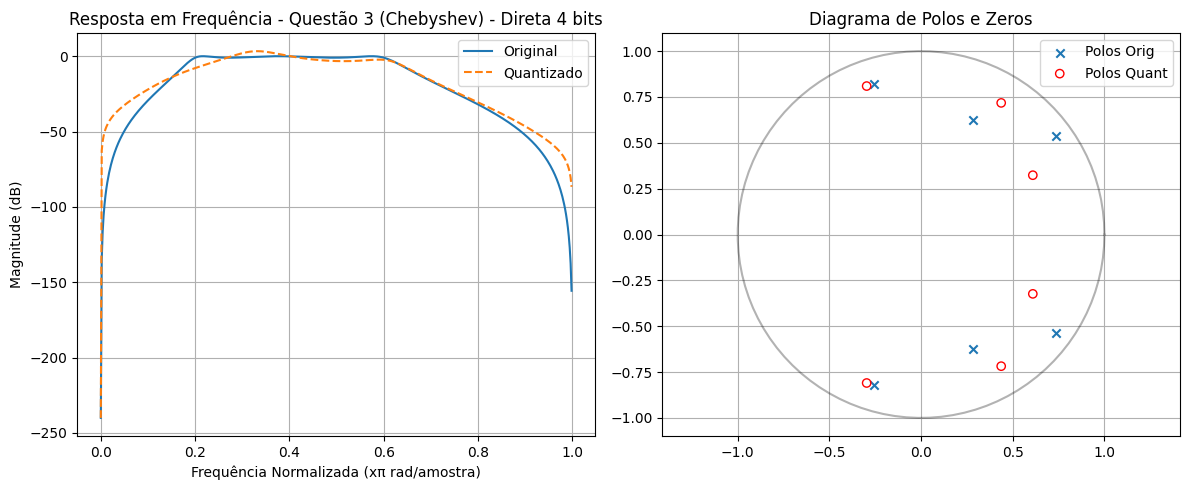

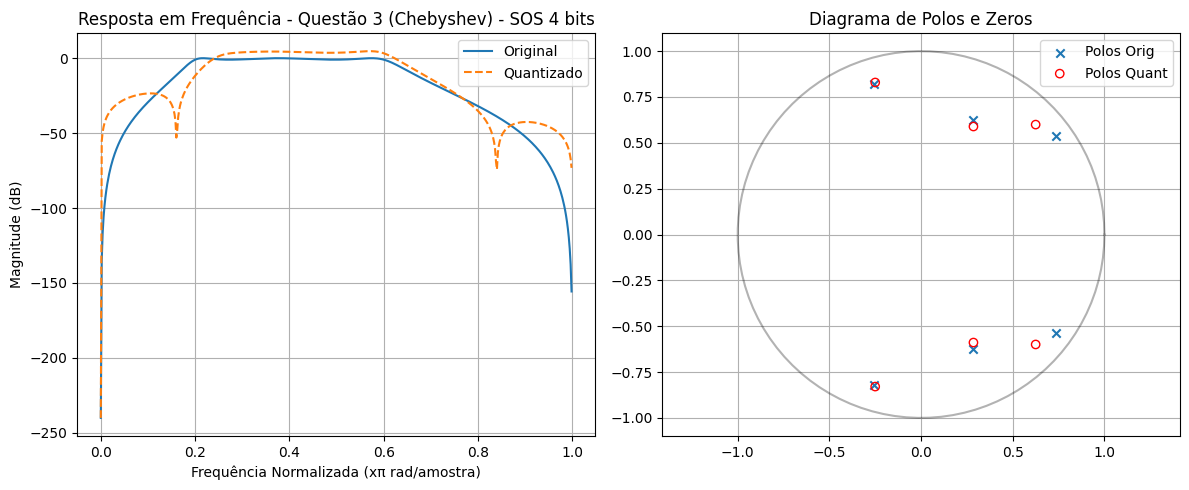

Bits: 8 | Estável (Direta): True

Gerando gráficos para 8 bits...


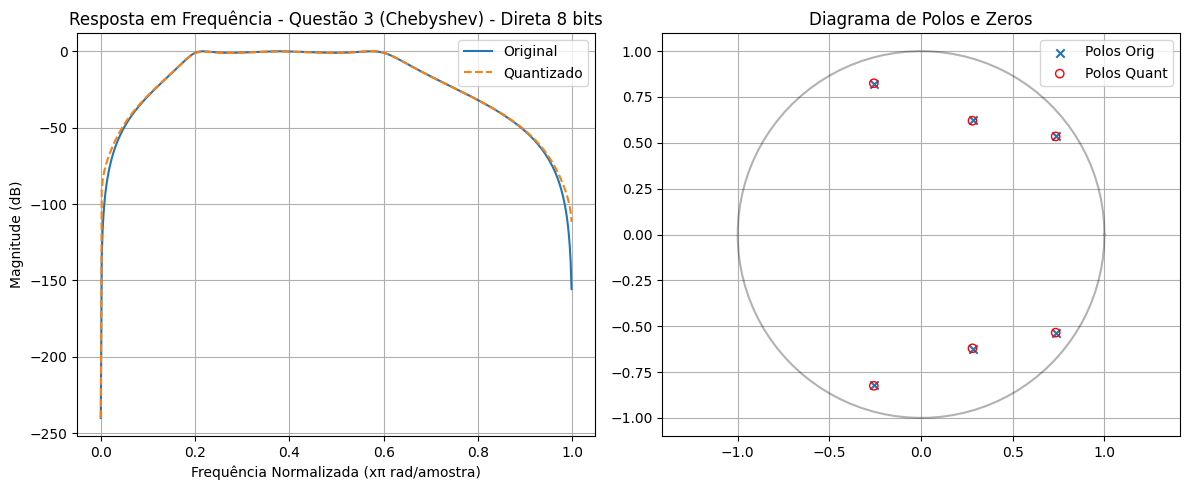

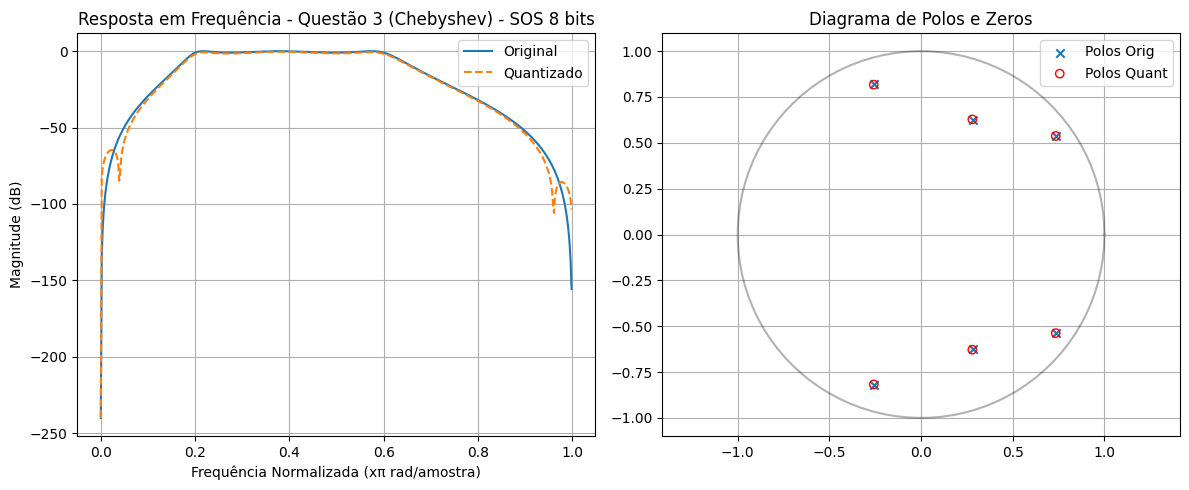

Bits: 16 | Estável (Direta): True

Gerando gráficos para 16 bits...


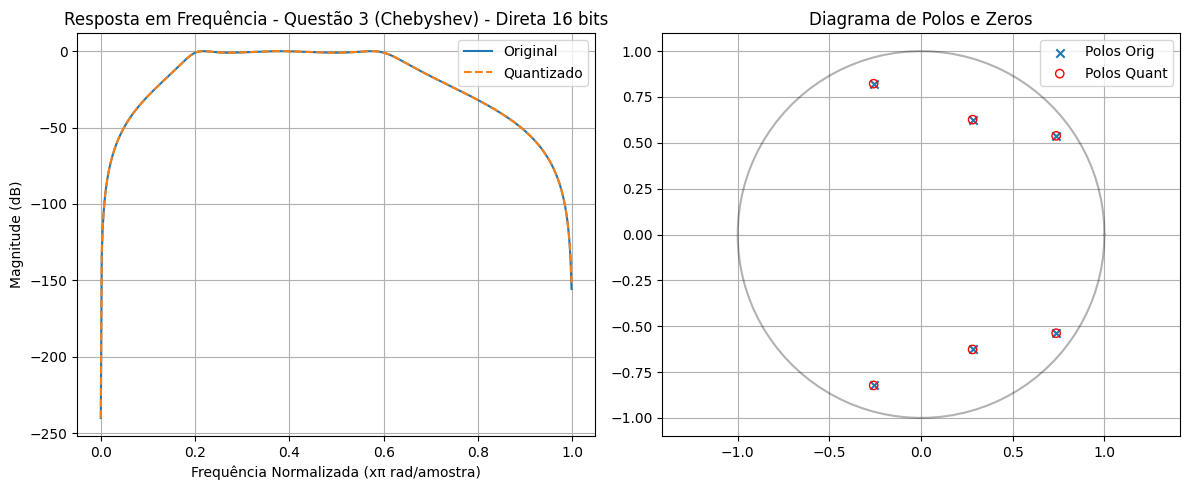

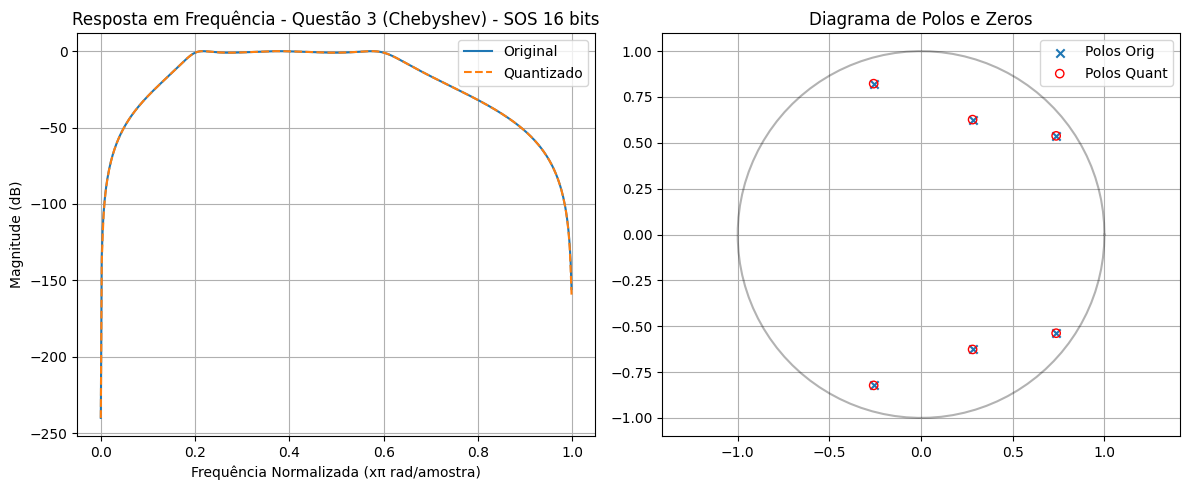

Bits: 32 | Estável (Direta): True


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Usando os coeficientes já presentes no Kernel (a2, b2, sos2, a3, b3, sos3)
# Estes foram gerados nas células anteriores e representam os filtros das Q2 e Q3

def run_full_analysis(b_orig, a_orig, sos_orig, name):
    bits_to_test = [2, 4, 8, 16, 32]
    print(f'\n--- Analisando {name} ---')

    for b in bits_to_test:
        # 1. Quantização Forma Direta
        bq = quantize_coefficients(b_orig, b)
        aq = quantize_coefficients(a_orig, b)

        # 2. Quantização SOS
        sos_q = np.array([quantize_coefficients(sec, b) for sec in sos_orig])

        # Verificação de estabilidade (Polos)
        z_dir, p_dir, k_dir = signal.tf2zpk(bq, aq)
        stable_dir = np.all(np.abs(p_dir) < 1.0)

        print(f'Bits: {b} | Estável (Direta): {stable_dir}')

        if b in [4, 8, 16]: # Visualização para casos críticos solicitados
            print(f'\nGerando gráficos para {b} bits...')
            # Forma Direta
            plot_comparison(b_orig, a_orig, bq, aq, f'{name} - Direta {b} bits')
            # Forma SOS
            bq_sos, aq_sos = signal.sos2tf(sos_q)
            plot_comparison(b_orig, a_orig, bq_sos, aq_sos, f'{name} - SOS {b} bits')

# Executa a análise para ambos os filtros
run_full_analysis(b2, a2, sos2, 'Questão 2 (Butterworth)')
run_full_analysis(b3, a3, sos3, 'Questão 3 (Chebyshev)')

### Análise dos Resultados e Comentários

**1. Sensibilidade Numérica:**
A implementação em **Forma Direta** demonstrou alta sensibilidade, especialmente para o filtro de Chebyshev (Questão 3), que possui ordem mais elevada e polos mais próximos do círculo unitário. Com menos de 16 bits, a resposta em frequência da forma direta sofre distorções severas (erros de ganho e deslocamento de frequências de corte).

**2. Estabilidade:**
Em níveis baixos de bits (2 e 4 bits), os polos do filtro em forma direta frequentemente se deslocam para fora do círculo unitário ($|z| \ge 1$), tornando o sistema **instável**. A quantização dos coeficientes do denominador $a(n)$ é crítica, pois pequenas variações alteram drasticamente o comportamento recursivo.

**3. Vantagem do SOS (Seções de Segunda Ordem):**
A decomposição em seções SOS mostrou-se muito mais robusta. Como cada seção lida apenas com polinômios de 2ª ordem, a dispersão das raízes causada pelo arredondamento é minimizada. Mesmo com 8 bits, a estrutura SOS preserva a forma do filtro, enquanto a forma direta já apresenta degradação significativa.

**4. Conclusão:**
Para implementações em hardware de baixo custo ou DSPs de ponto fixo, a estrutura **SOS é mandatória**. O uso de 32 bits (ponto flutuante) elimina problemas de quantização, mas em sistemas restritos, 16 bits em SOS oferece um balanço ideal entre custo computacional e fidelidade de resposta.